# Feb. 16th 2026 - Revisted for Enhanced Model

In [1]:
import pandas as pd
import numpy as np
import ast
from scipy import stats
from itertools import chain
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import MultiLabelBinarizer
import scipy.sparse as sp
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

## Getting the Data Ready

In [2]:
#raw_interactions = pd.read_csv("RAW_interactions.csv")
raw_recipes = pd.read_csv("RAW_recipes.csv")

In [3]:
len(raw_recipes)

83782

In [4]:
raw_recipes.columns

Index(['Unnamed: 0', 'name', 'id', 'minutes', 'contributor_id', 'submitted',
       'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='str')

In [5]:
#RR = pd.merge(raw_recipes, raw_interactions, left_on = 'id', right_on = 'recipe_id', how = 'left')

In [6]:
#RR['rating'] = RR['rating'].replace(0, np.nan)

In [7]:
#average_ratings = RR.groupby('name')['rating'].mean()

In [8]:
#recipes = raw_recipes.merge(average_ratings.rename('average_rating'), on='name', how='left')

In [9]:
recipes = raw_recipes

In [10]:
recipes

,Unnamed: 0,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,111,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9
1,115,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11
2,118,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9
3,119,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7
4,125,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83777,231632,zydeco soup,486161,60,227978,2012-08-29,"['ham', '60-minutes-or-less', 'time-to-make', ...","[415.2, 26.0, 34.0, 26.0, 44.0, 21.0, 15.0]",7,"['heat oil in a 4-quart dutch oven', 'add cele...",this is a delicious soup that i originally fou...,"['celery', 'onion', 'green sweet pepper', 'gar...",22
83778,231633,zydeco spice mix,493372,5,1500678,2013-01-09,"['15-minutes-or-less', 'time-to-make', 'course...","[14.8, 0.0, 2.0, 58.0, 1.0, 0.0, 1.0]",1,['mix all ingredients together thoroughly'],this spice mix will make your taste buds dance!,"['paprika', 'salt', 'garlic powder', 'onion po...",13
83779,231634,zydeco ya ya deviled eggs,308080,40,37779,2008-06-07,"['60-minutes-or-less', 'time-to-make', 'course...","[59.2, 6.0, 2.0, 3.0, 6.0, 5.0, 0.0]",7,"['in a bowl , combine the mashed yolks and may...","deviled eggs, cajun-style","['hard-cooked eggs', 'mayonnaise', 'dijon must...",8
83780,231635,cookies by design cookies on a stick,298512,29,506822,2008-04-15,"['30-minutes-or-less', 'time-to-make', 'course...","[188.0, 11.0, 57.0, 11.0, 7.0, 21.0, 9.0]",9,['place melted butter in a large mixing bowl a...,"i've heard of the 'cookies by design' company,...","['butter', 'eagle brand condensed milk', 'ligh...",10


In [11]:
recipes['ingredients'] = recipes['ingredients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [12]:
recipes['tags'] = recipes['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [13]:
def clean_token_list(tokens):
    if not isinstance(tokens, list):
        return []
    cleaned = []
    seen = set()
    for t in tokens:
        if not isinstance(t, str):
            continue
        s = t.strip().lower()
        if s == "":
            continue
        if s not in seen:
            cleaned.append(s)
            seen.add(s)
    return cleaned

In [14]:
recipes["ingredients"] = recipes["ingredients"].apply(clean_token_list)

In [15]:
recipes["tags"] = recipes["tags"].apply(clean_token_list)

In [16]:
recipes["tags"] = recipes["tags"].apply(lambda t: t if len(t) > 0 else ["__NO_TAG__"])

In [17]:
recipes = recipes[recipes["ingredients"].str.len() > 0].copy()

In [18]:
Q1 = recipes['minutes'].quantile(0.25)
Q3 = recipes['minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = recipes[(recipes['minutes'] < lower_bound) | 
                           (recipes['minutes'] > upper_bound)]
print(f"\nOutliers using IQR method: {len(iqr_outliers)}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(iqr_outliers.head())


Outliers using IQR method: 7991
Lower bound: -47.5, Upper bound: 132.5
    Unnamed: 0                                name      id  minutes  \
6          132         50 chili   for the crockpot  501028      345   
11         139  rter med flsk   pea soup with pork  333797      195   
12         140    rtsoppa  swedish yellow pea soup  428056      150   
34         257        posh   pork roast   crockpot  451515      315   
39         266               russian  dressing  ww  276567      135   

    contributor_id   submitted  \
6          2628680  2013-05-28   
11           64642  2008-10-29   
12          618715  2010-06-01   
34           50969  2011-03-24   
39          305531  2008-01-05   

                                                 tags  \
6   [course, main-ingredient, cuisine, preparation...   
11  [time-to-make, course, main-ingredient, cuisin...   
12  [time-to-make, course, main-ingredient, cuisin...   
34  [course, main-ingredient, cuisine, preparation...   
39  [time-t

In [19]:
median = recipes['minutes'].median()
mad = stats.median_abs_deviation(recipes['minutes'])
modified_z_scores = 0.6745 * (recipes['minutes'] - median) / mad
recipes['modified_z_scores'] = modified_z_scores
mod_z_outliers = recipes[abs(modified_z_scores) > 3.5]
print(f"\nOutliers using Modified Z-score method: {len(mod_z_outliers)}")
print(mod_z_outliers.head())


Outliers using Modified Z-score method: 7496
    Unnamed: 0                                name      id  minutes  \
6          132         50 chili   for the crockpot  501028      345   
11         139  rter med flsk   pea soup with pork  333797      195   
12         140    rtsoppa  swedish yellow pea soup  428056      150   
34         257        posh   pork roast   crockpot  451515      315   
46         289                    the  carrot cake  325714     1500   

    contributor_id   submitted  \
6          2628680  2013-05-28   
11           64642  2008-10-29   
12          618715  2010-06-01   
34           50969  2011-03-24   
46          817632  2008-09-19   

                                                 tags  \
6   [course, main-ingredient, cuisine, preparation...   
11  [time-to-make, course, main-ingredient, cuisin...   
12  [time-to-make, course, main-ingredient, cuisin...   
34  [course, main-ingredient, cuisine, preparation...   
46  [time-to-make, course, preparatio

In [20]:
len(mod_z_outliers)

7496

In [21]:
recipes_clean = recipes[abs(recipes['modified_z_scores']) <= 3.5].copy()
print(f"Original dataset size: {len(recipes)}")
print(f"Clean dataset size: {len(recipes_clean)}")
print(f"Removed {len(recipes) - len(recipes_clean)} outliers")

Original dataset size: 83782
Clean dataset size: 76286
Removed 7496 outliers


In [22]:
recipes_clean = recipes_clean[['ingredients', 'tags', 'minutes']]

In [23]:
recipes_clean

,ingredients,tags,minutes
0,"[bittersweet chocolate, unsalted butter, eggs,...","[60-minutes-or-less, time-to-make, course, mai...",40
1,"[white sugar, brown sugar, salt, margarine, eg...","[60-minutes-or-less, time-to-make, cuisine, pr...",45
2,"[frozen broccoli cuts, cream of chicken soup, ...","[60-minutes-or-less, time-to-make, course, mai...",40
3,"[butter, sugar, eggs, all-purpose flour, whole...","[time-to-make, course, cuisine, preparation, o...",120
4,"[meatloaf mixture, unsmoked bacon, goat cheese...","[time-to-make, course, main-ingredient, prepar...",90
...,...,...,...
83777,"[celery, onion, green sweet pepper, garlic clo...","[ham, 60-minutes-or-less, time-to-make, course...",60
83778,"[paprika, salt, garlic powder, onion powder, d...","[15-minutes-or-less, time-to-make, course, pre...",5
83779,"[hard-cooked eggs, mayonnaise, dijon mustard, ...","[60-minutes-or-less, time-to-make, course, mai...",40
83780,"[butter, eagle brand condensed milk, light bro...","[30-minutes-or-less, time-to-make, course, pre...",29


## Model Pipeline

In [24]:
X = recipes_clean[['ingredients', 'tags']]

In [25]:
y = recipes_clean['minutes']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, random_state = 44)

In [27]:
X_train, y_train

(                                             ingredients  \
 82049  [white whole wheat flour, baking powder, salt,...   
 43260  [onion, water, beef bouillon granules, garlic ...   
 80305  [lasagna noodles, spaghetti sauce, plain yogur...   
 66819  [raw shrimp, carrot, green onion, garlic, fres...   
 77904  [spinach and cheese tortellini, reduced-fat it...   
 ...                                                  ...   
 58210  [ground chuck, onion, worcestershire sauce, co...   
 54564  [canola oil, cumin seed, panir, scallions, fre...   
 28441  [butter, flour, vanilla sugar, sugar, egg, cur...   
 75928  [flank steaks, chili sauce, jalapeno, fish sau...   
 15288  [coconut oil, celery hearts, sweet onion, butt...   
 
                                                     tags  
 82049  [30-minutes-or-less, time-to-make, course, pre...  
 43260  [lactose, 60-minutes-or-less, time-to-make, co...  
 80305  [time-to-make, course, main-ingredient, prepar...  
 66819  [30-minutes-or-les

In [28]:
mlb_ingredients = MultiLabelBinarizer(sparse_output=True)
train_ingredients = mlb_ingredients.fit_transform(X_train['ingredients'])

In [29]:
mlb_tags = MultiLabelBinarizer(sparse_output=True)
train_tags = mlb_tags.fit_transform(X_train['tags'])

In [30]:
test_ingredients = mlb_ingredients.transform(X_test['ingredients'])

/Users/jhkim/miniforge3/envs/RR_enhanced/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['2% large-curd cottage cheese', '6 inch fat-free whole wheat pita bread', '8-inch flour tortillas', '9-inch baked pie crust', '97% lean ground beef', '98% fat free condensed cream of celery soup', '99% fat free orange flavored yogurt', 'a.1. steak sauce', 'abalone steak', 'achiote seeds', 'aguardiente', 'aji panca chile', 'alligator meat', 'alligator tail steaks', 'almond cookie', 'almond halve', 'almond halves', 'almond powder', 'amaretto cookies', 'animal crackers', 'anise-flavored liqueur', 'apple crumble mix', 'apricot liqueur', 'aromatic bitters', 'artichoke pesto', 'atkins baking mix', "aunt jane's krazy mixed up salt", 'baby artichoke', 'bacon cheddar cheese', 'baileys caramel irish cream', 'baked beans with molasses', "baker's angel flake sweetened coconut", "baker's joy", 'balkan style yogurt', 'banana ice cream', 'banana ketchup', 'banana

In [31]:
test_tags = mlb_tags.transform(X_test['tags'])

/Users/jhkim/miniforge3/envs/RR_enhanced/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['beef-kidney', 'lasagne', 'less_thansql:name_topics_of_recipegreater_than'] will be ignored
  warnings.warn(


In [32]:
train_stack = sp.hstack([train_ingredients, train_tags], format='csr')

In [33]:
test_stack = sp.hstack([test_ingredients, test_tags], format='csr')

In [34]:
train_stack

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1554068 stored elements and shape (61028, 10594)>

In [35]:
y_train

82049    24
43260    45
80305    90
66819    25
77904    16
         ..
58210    45
54564    10
28441    20
75928    20
15288    55
Name: minutes, Length: 61028, dtype: int64

Lot of unknown classes. Common for high-cardinality sparse features. Baseline model for quick sanity and reference point. Making sure to: validate preprocessing pipeline, set a performance floor. 

## Baseline Model - Dummy Regressor

In [36]:
dummy_regr = DummyRegressor(strategy='mean')
dummy_regr.fit(train_stack, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [37]:
dummy_pred = dummy_regr.predict(test_stack)
#R^2
dummy_regr.score(test_stack, y_test)

-2.409201579567366e-06

In [38]:
#MAE
mean_absolute_error( y_test, dummy_pred)

21.44248602222284

In [39]:
#RMSE
root_mean_squared_error(y_test, dummy_pred)

27.43792876352582

## Baseline Model - ElasticNet

In [40]:
regr = ElasticNet(random_state = 68)
regr.fit(train_stack, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",68
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [41]:
pred = regr.predict(test_stack)
regr.score(test_stack, y_test)

0.4418245369814927

In [42]:
mean_absolute_error(y_test, pred)

15.540533955152153

In [43]:
root_mean_squared_error(y_test, pred)

20.499165027370328

You can see that ElasticNet model does perform better meaning our prerprocessing pipeline is working and the model is learning singals. Our earlier concern about unknown classes are also proven to be not fatal. On to XGBoost

## XGBoost Model

In [44]:
xgb = XGBRegressor(
    objective = 'reg:squarederror',
    tree_method = 'hist',
    random_state = 27, 
    n_jobs = -1
)

In [45]:
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 3, 10]
}

In [46]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 44)

In [47]:
search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dist,
    n_iter = 25,
    scoring = 'neg_root_mean_squared_error',
    cv = cv,
    random_state = 44,
    verbose = 2,
    n_jobs = -1,
    refit = True
)

In [48]:
search.fit(train_stack, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   7.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   8.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   8.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   9.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   9.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0

In [49]:
best_xgb = search.best_estimator_
xgb_pred = best_xgb.predict(test_stack)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGB Test RMSE: {xgb_rmse:.3f}")
print(f"XGB Test MAE : {xgb_mae:.3f}")
print(f"XGB Test R^2 : {xgb_r2:.3f}")

XGB Test RMSE: 10.006
XGB Test MAE : 6.870
XGB Test R^2 : 0.867


## XGBoost Second Round Tuning

In [50]:
param_dist_2 = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.02, 0.03, 0.04],
    "max_depth": [7, 8, 9],
    "min_child_weight": [2, 3, 4],
    "subsample": [0.65, 0.70, 0.75],
    "colsample_bytree": [0.50, 0.60, 0.70],
    "reg_alpha": [0.0, 0.01, 0.05],
    "reg_lambda": [2, 3, 5],
    "gamma": [0.0, 0.5, 1.0]
}

In [51]:
cv_2 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=44
)

In [52]:
search_2 = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_2,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv_2,
    random_state=44,
    verbose=2,
    n_jobs=-1,
    refit=True
)

In [53]:
search_2.fit(train_stack, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=2, n_estimators=300, reg_alpha=0.0, reg_lambda=5, subsample=0.65; total time= 2.7min
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=2, n_estimators=300, reg_alpha=0.0, reg_lambda=5, subsample=0.65; total time= 2.7min
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=2, n_estimators=300, reg_alpha=0.0, reg_lambda=5, subsample=0.65; total time= 2.7min
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=2, n_estimators=300, reg_alpha=0.0, reg_lambda=5, subsample=0.65; total time= 2.7min
[CV] END colsample_bytree=0.5, gamma=0.5, learning_rate=0.03, max_depth=9, min_child_weight=3, n_estimators=300, reg_alpha=0.0, reg_lambda=5, subsample=0.75; total time= 2.7min
[CV] END colsample_bytree=0.7, gamma=0.0, learning_ra

In [54]:
best_xgb = search_2.best_estimator_
xgb_pred = best_xgb.predict(test_stack)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGB Test RMSE: {xgb_rmse:.3f}")
print(f"XGB Test MAE : {xgb_mae:.3f}")
print(f"XGB Test R^2 : {xgb_r2:.3f}")

XGB Test RMSE: 9.998
XGB Test MAE : 6.851
XGB Test R^2 : 0.867


## Residual Analysis

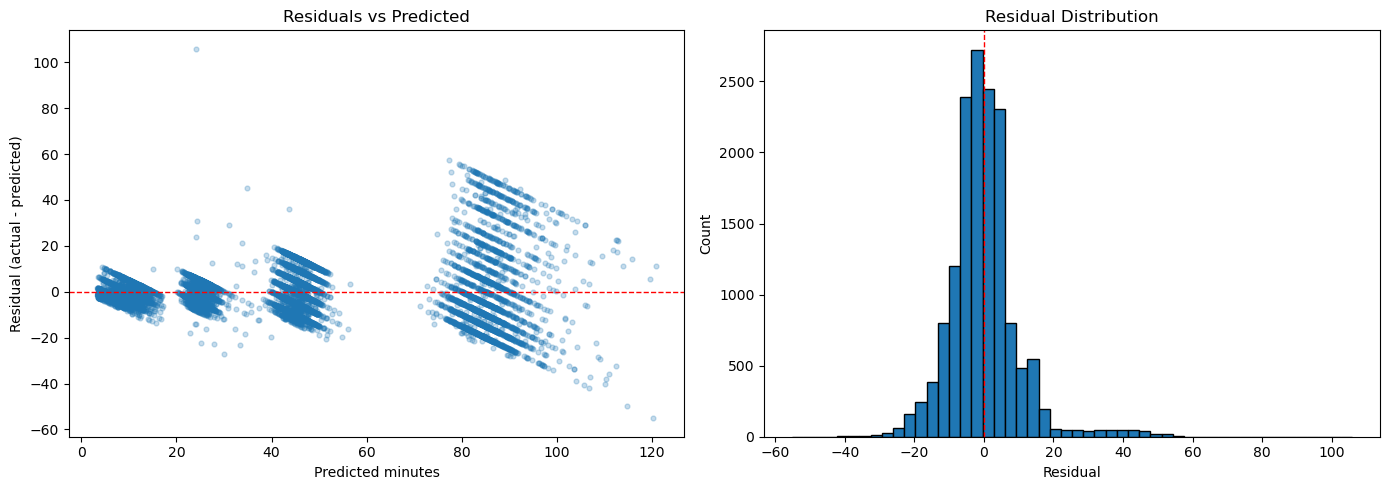

In [55]:
# Ensure same index alignment
y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(xgb_pred).reset_index(drop=True)

residuals = y_test_series - y_pred_series

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_series, residuals, alpha=0.25, s=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Predicted minutes")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## Error by Bins

In [56]:
eval_df = pd.DataFrame({
    "actual": y_test_series,
    "pred": y_pred_series
})
eval_df["abs_error"] = (eval_df["actual"] - eval_df["pred"]).abs()
eval_df["sq_error"] = (eval_df["actual"] - eval_df["pred"]) ** 2

# Adjust bins if you want finer granularity
bins = [0, 15, 30, 45, 60, 90, 120, np.inf]
labels = ["0-15", "15-30", "30-45", "45-60", "60-90", "90-120", "120+"]

eval_df["minute_bin"] = pd.cut(eval_df["actual"], bins=bins, labels=labels, right=False)

bin_summary = (
    eval_df.groupby("minute_bin", observed=False)
    .agg(
        n=("actual", "size"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        actual_mean=("actual", "mean"),
        pred_mean=("pred", "mean")
    )
    .reset_index()
)

bin_summary

,minute_bin,n,mae,rmse,actual_mean,pred_mean
0,0-15,2401,2.718524,3.536632,7.088297,8.855462
1,15-30,3614,3.316556,4.014885,20.368567,21.414278
2,30-45,3655,6.540004,7.255334,34.605746,37.653969
3,45-60,2093,4.311910,5.528227,49.231247,45.805298
4,60-90,2530,12.824899,14.231722,68.896047,73.031868
5,90-120,624,12.028154,14.450410,97.950321,86.434967
6,120+,341,38.540102,39.712610,127.642229,89.102127


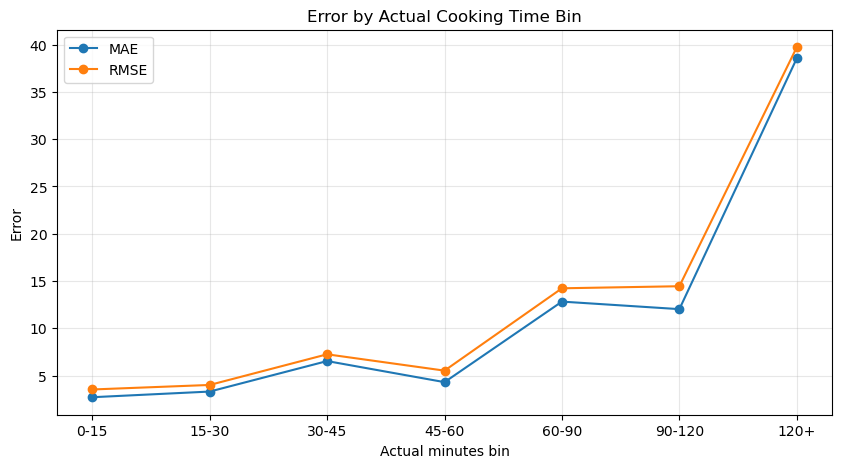

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(bin_summary["minute_bin"].astype(str), bin_summary["mae"], marker="o", label="MAE")
plt.plot(bin_summary["minute_bin"].astype(str), bin_summary["rmse"], marker="o", label="RMSE")
plt.xlabel("Actual minutes bin")
plt.ylabel("Error")
plt.title("Error by Actual Cooking Time Bin")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Feature Importance

In [58]:
# Build feature names from your MLB encoders
feature_names = (
    [f"ing::{c}" for c in mlb_ingredients.classes_] +
    [f"tag::{c}" for c in mlb_tags.classes_]
)

# XGBoost native importance (gain-based)
booster = best_xgb.get_booster()
score_gain = booster.get_score(importance_type="gain")  # keys like 'f0', 'f1', ...

# Convert to readable table
rows = []
for k, v in score_gain.items():
    idx = int(k[1:])  # from "f123" -> 123
    name = feature_names[idx] if idx < len(feature_names) else k
    rows.append((name, v))

importance_gain_df = pd.DataFrame(rows, columns=["feature", "gain_importance"])
importance_gain_df = importance_gain_df.sort_values("gain_importance", ascending=False).reset_index(drop=True)

importance_gain_df.head(20)

,feature,gain_importance
0,tag::4-hours-or-less,1.291421e+06
1,tag::15-minutes-or-less,4.460066e+05
2,tag::30-minutes-or-less,1.747255e+05
3,tag::60-minutes-or-less,1.450001e+05
4,tag::for-1-or-2,3.154613e+04
5,tag::beverages,2.320005e+04
6,tag::easy,1.938682e+04
7,tag::3-steps-or-less,1.413294e+04
8,tag::crock-pot-slow-cooker,1.145203e+04
9,ing::lasagna noodles,1.134538e+04


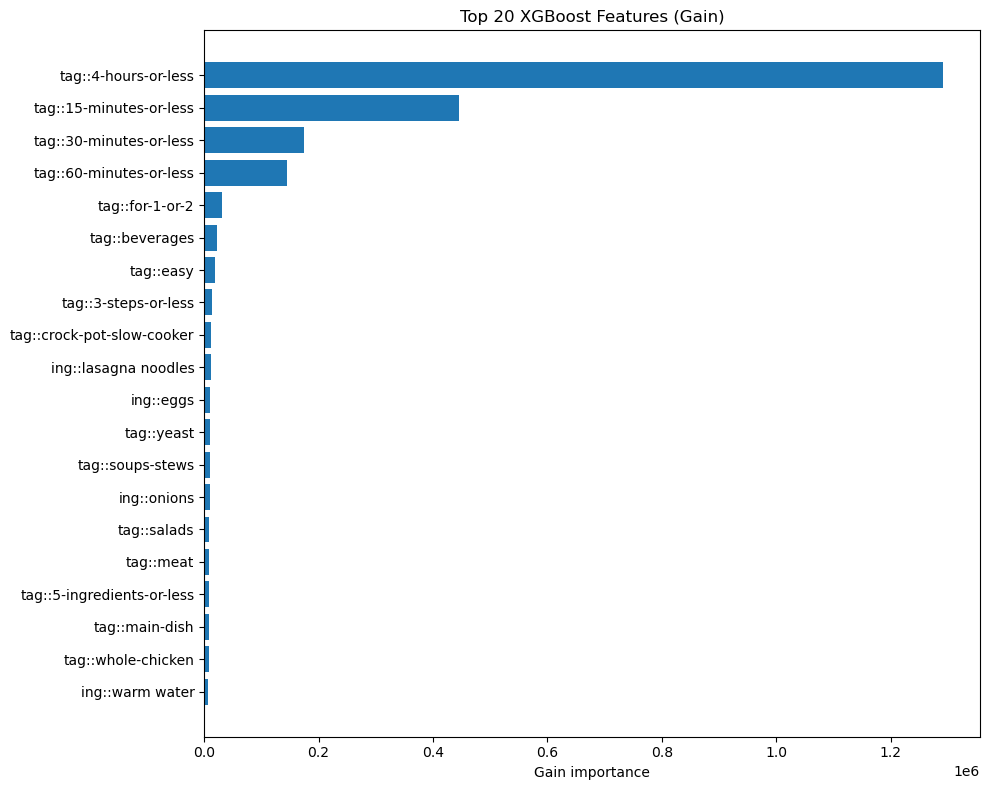

In [59]:
top_n = 20
top_gain = importance_gain_df.head(top_n).iloc[::-1]  # reverse for horizontal bar chart

plt.figure(figsize=(10, 8))
plt.barh(top_gain["feature"], top_gain["gain_importance"])
plt.xlabel("Gain importance")
plt.title(f"Top {top_n} XGBoost Features (Gain)")
plt.tight_layout()
plt.show()